In [747]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [748]:
PROJECT_PATH = "/content/drive/MyDrive/VPNVision/Flow_engine"

RAW_PATH = PROJECT_PATH + "/raw"
PROCESSED_PATH = PROJECT_PATH + "/processed"
PREPROCESSING_PATH = PROJECT_PATH + "/preprocessing"
MODELS_PATH = PROJECT_PATH + "/models"
REPORTS_PATH = PROJECT_PATH + "/reports"

print(PROJECT_PATH)

/content/drive/MyDrive/VPNVision/Flow_engine


In [749]:
import os

csv_path = RAW_PATH + "/consolidated_traffic_data.csv"

print("CSV exists:", os.path.exists(csv_path))
print("CSV path:", csv_path)

CSV exists: True
CSV path: /content/drive/MyDrive/VPNVision/Flow_engine/raw/consolidated_traffic_data.csv


In [750]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully")

Libraries imported successfully


In [751]:
df = pd.read_csv(csv_path)

print("Dataset loaded successfully")

Dataset loaded successfully


In [752]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 59706
Columns: 24


In [753]:
df.head()

,duration,total_fiat,total_biat,min_fiat,min_biat,max_fiat,max_biat,mean_fiat,mean_biat,flowPktsPerSecond,...,std_flowiat,min_active,mean_active,max_active,std_active,min_idle,mean_idle,max_idle,std_idle,traffic_type
0,119994459.0,119994459.0,119970125.0,0.0,0.0,1399330.0,1211310.0,2348.136257,513.267526,2373.792943,...,9107.759178,1753114.0,11300000.0,39438693.0,1.600000e+07,1014624.0,1139537.6,1208289.0,74997.385381,BROWSING
1,143704195.0,143704195.0,42106019.0,0.0,0.0,101572528.0,854818.0,6986.105737,636.898837,603.204381,...,345078.175888,143704195.0,144000000.0,143704195.0,0.000000e+00,101572528.0,102000000.0,101572528.0,0.000000,BROWSING
2,119994980.0,119994980.0,119966891.0,7.0,0.0,819852.0,819602.0,10201.919742,2341.411304,525.030297,...,17736.017265,-1.0,0.0,-1.0,0.000000e+00,-1.0,0.0,-1.0,0.000000,BROWSING
3,119292282.0,119292282.0,119260024.0,3.0,0.0,912990.0,866900.0,11947.148923,3354.712349,381.726288,...,24218.472201,-1.0,0.0,-1.0,0.000000e+00,-1.0,0.0,-1.0,0.000000,BROWSING
4,119772966.0,119772917.0,119772939.0,4.0,0.0,2894671.0,2923147.0,18210.873803,3644.280989,329.331412,...,31326.437353,2210292.0,8688035.0,15165778.0,9.160912e+06,1799762.0,2347216.5,2894671.0,774217.578682,BROWSING


In [754]:
df.tail()


,duration,total_fiat,total_biat,min_fiat,min_biat,max_fiat,max_biat,mean_fiat,mean_biat,flowPktsPerSecond,...,std_flowiat,min_active,mean_active,max_active,std_active,min_idle,mean_idle,max_idle,std_idle,traffic_type
59701,22829253.0,22829253.0,0.0,350190.0,-1.0,10002514.0,-1.0,3804875.5,0.0,0.306624,...,3.855394e+06,2001173.0,5707313.25,10002514.0,3.480152e+06,2001173.0,5507044.0,10002514.0,3.630735e+06,VPN-VOIP
59702,895.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,2234.636872,...,0.000000e+00,-1.0,0.00,-1.0,0.000000e+00,-1.0,0.0,-1.0,0.000000e+00,VPN-VOIP
59703,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.000000,...,0.000000e+00,-1.0,0.00,-1.0,0.000000e+00,-1.0,0.0,-1.0,0.000000e+00,VPN-VOIP
59704,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.000000,...,0.000000e+00,-1.0,0.00,-1.0,0.000000e+00,-1.0,0.0,-1.0,0.000000e+00,VPN-VOIP
59705,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.000000,...,0.000000e+00,-1.0,0.00,-1.0,0.000000e+00,-1.0,0.0,-1.0,0.000000e+00,VPN-VOIP


In [755]:
print(df.columns.tolist())

['duration', 'total_fiat', 'total_biat', 'min_fiat', 'min_biat', 'max_fiat', 'max_biat', 'mean_fiat', 'mean_biat', 'flowPktsPerSecond', 'flowBytesPerSecond', 'min_flowiat', 'max_flowiat', 'mean_flowiat', 'std_flowiat', 'min_active', 'mean_active', 'max_active', 'std_active', 'min_idle', 'mean_idle', 'max_idle', 'std_idle', 'traffic_type']


In [756]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,59706.0,2.354579e+07,3.610462e+07,0.0,256160.000000,1.306654e+07,2.998854e+07,646565983.0
total_fiat,59706.0,2.215066e+07,3.465348e+07,0.0,111687.500000,1.168921e+07,2.993403e+07,646565983.0
total_biat,59706.0,2.049105e+07,2.968948e+07,0.0,2625.000000,1.028447e+07,2.968528e+07,601185122.0
min_fiat,59706.0,2.044648e+06,7.919716e+06,-1.0,7.000000,6.400000e+01,3.090250e+03,119999708.0
min_biat,59706.0,1.779203e+06,7.455655e+06,-1.0,0.000000,2.000000e+01,5.037500e+02,119999620.0
max_fiat,59706.0,9.063199e+06,2.522047e+07,-1.0,25972.000000,5.371380e+05,9.829409e+06,646287731.0
max_biat,59706.0,7.591169e+06,1.704812e+07,-1.0,1738.000000,3.828470e+05,9.521396e+06,600109667.0
mean_fiat,59706.0,3.190482e+06,9.150407e+06,0.0,7927.111931,1.016749e+05,1.071742e+06,152000000.0
mean_biat,59706.0,2.776105e+06,8.073066e+06,0.0,336.445092,5.391917e+04,9.615569e+05,120000000.0
flowPktsPerSecond,59706.0,4.035707e+03,2.858908e+04,0.0,0.959502,8.545710e+00,1.001268e+02,2000000.0


In [757]:
missing = df.isnull().sum()

print(missing)
missing[missing > 0]

duration              0
total_fiat            0
total_biat            0
min_fiat              0
min_biat              0
max_fiat              0
max_biat              0
mean_fiat             0
mean_biat             0
flowPktsPerSecond     0
flowBytesPerSecond    0
min_flowiat           0
max_flowiat           0
mean_flowiat          0
std_flowiat           0
min_active            0
mean_active           0
max_active            0
std_active            0
min_idle              0
mean_idle             0
max_idle              0
std_idle              0
traffic_type          0
dtype: int64


,0


In [758]:
numeric_df = df.select_dtypes(include=np.number)

infinite_counts = np.isinf(numeric_df).sum()

print(infinite_counts[infinite_counts > 0])

Series([], dtype: int64)


In [759]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 18719


In [760]:
constant_columns = [
    col for col in df.columns
    if df[col].nunique(dropna=False) <= 1
]

print("Constant columns:")
print(constant_columns)

Constant columns:
[]


In [761]:
print(df['traffic_type'].value_counts())

traffic_type
BROWSING         10000
VPN-BROWSING     10000
VOIP              6485
VPN-VOIP          5576
VPN-FT            4704
P2P               4000
FT                3975
VPN-P2P           3415
VPN-CHAT          2839
CHAT              2505
VPN-MAIL          2444
MAIL              1364
STREAMING         1284
VPN-STREAMING     1115
Name: count, dtype: int64


In [762]:
print("Number of traffic classes:",
      df['traffic_type'].nunique())

Number of traffic classes: 14


In [763]:
print("Traffic classes:")
print(df['traffic_type'].unique())

Traffic classes:
['BROWSING' 'CHAT' 'FT' 'MAIL' 'P2P' 'STREAMING' 'VOIP' 'VPN-BROWSING'
 'VPN-CHAT' 'VPN-FT' 'VPN-MAIL' 'VPN-P2P' 'VPN-STREAMING' 'VPN-VOIP']


In [764]:
class_counts = df['traffic_type'].value_counts()

print(class_counts)

traffic_type
BROWSING         10000
VPN-BROWSING     10000
VOIP              6485
VPN-VOIP          5576
VPN-FT            4704
P2P               4000
FT                3975
VPN-P2P           3415
VPN-CHAT          2839
CHAT              2505
VPN-MAIL          2444
MAIL              1364
STREAMING         1284
VPN-STREAMING     1115
Name: count, dtype: int64


In [765]:
class_percentages = df['traffic_type'].value_counts(normalize=True) * 100

print(class_percentages)

traffic_type
BROWSING         16.748735
VPN-BROWSING     16.748735
VOIP             10.861555
VPN-VOIP          9.339095
VPN-FT            7.878605
P2P               6.699494
FT                6.657622
VPN-P2P           5.719693
VPN-CHAT          4.754966
CHAT              4.195558
VPN-MAIL          4.093391
MAIL              2.284528
STREAMING         2.150538
VPN-STREAMING     1.867484
Name: proportion, dtype: float64


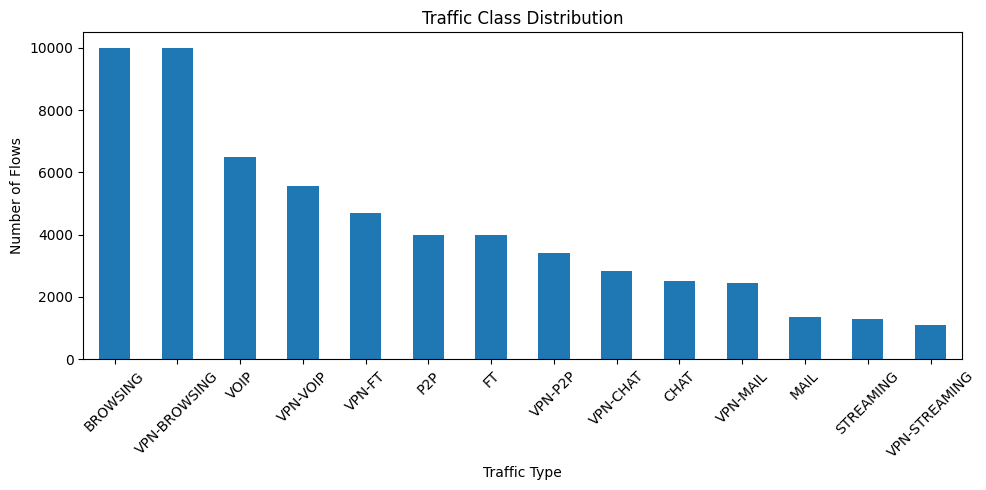

In [766]:
plt.figure(figsize=(10, 5))

class_counts.plot(kind='bar')

plt.title("Traffic Class Distribution")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Flows")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [767]:
unique_counts = df.nunique().sort_values()

print(unique_counts)

traffic_type             14
min_flowiat            6397
min_biat               7992
min_fiat               9134
mean_active           11740
mean_idle             12789
std_active            12904
std_idle              12933
min_idle              13843
min_active            14718
max_idle              16409
max_active            16872
max_biat              24806
max_fiat              26098
max_flowiat           28980
mean_biat             30172
mean_fiat             31523
std_flowiat           33085
total_biat            34452
total_fiat            35952
mean_flowiat          37911
duration              38926
flowPktsPerSecond     39829
flowBytesPerSecond    40425
dtype: int64


In [768]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['duration', 'total_fiat', 'total_biat', 'min_fiat', 'min_biat', 'max_fiat', 'max_biat', 'mean_fiat', 'mean_biat', 'flowPktsPerSecond', 'flowBytesPerSecond', 'min_flowiat', 'max_flowiat', 'mean_flowiat', 'std_flowiat', 'min_active', 'mean_active', 'max_active', 'std_active', 'min_idle', 'mean_idle', 'max_idle', 'std_idle']

Categorical columns:
['traffic_type']


In [769]:
negative_counts = (df[numeric_columns] < 0).sum()

print(negative_counts[negative_counts > 0])

min_fiat        8846
min_biat       13857
max_fiat        8846
max_biat       13857
min_flowiat     2694
max_flowiat     2108
min_active     32228
max_active     32228
min_idle       32228
max_idle       32228
dtype: int64


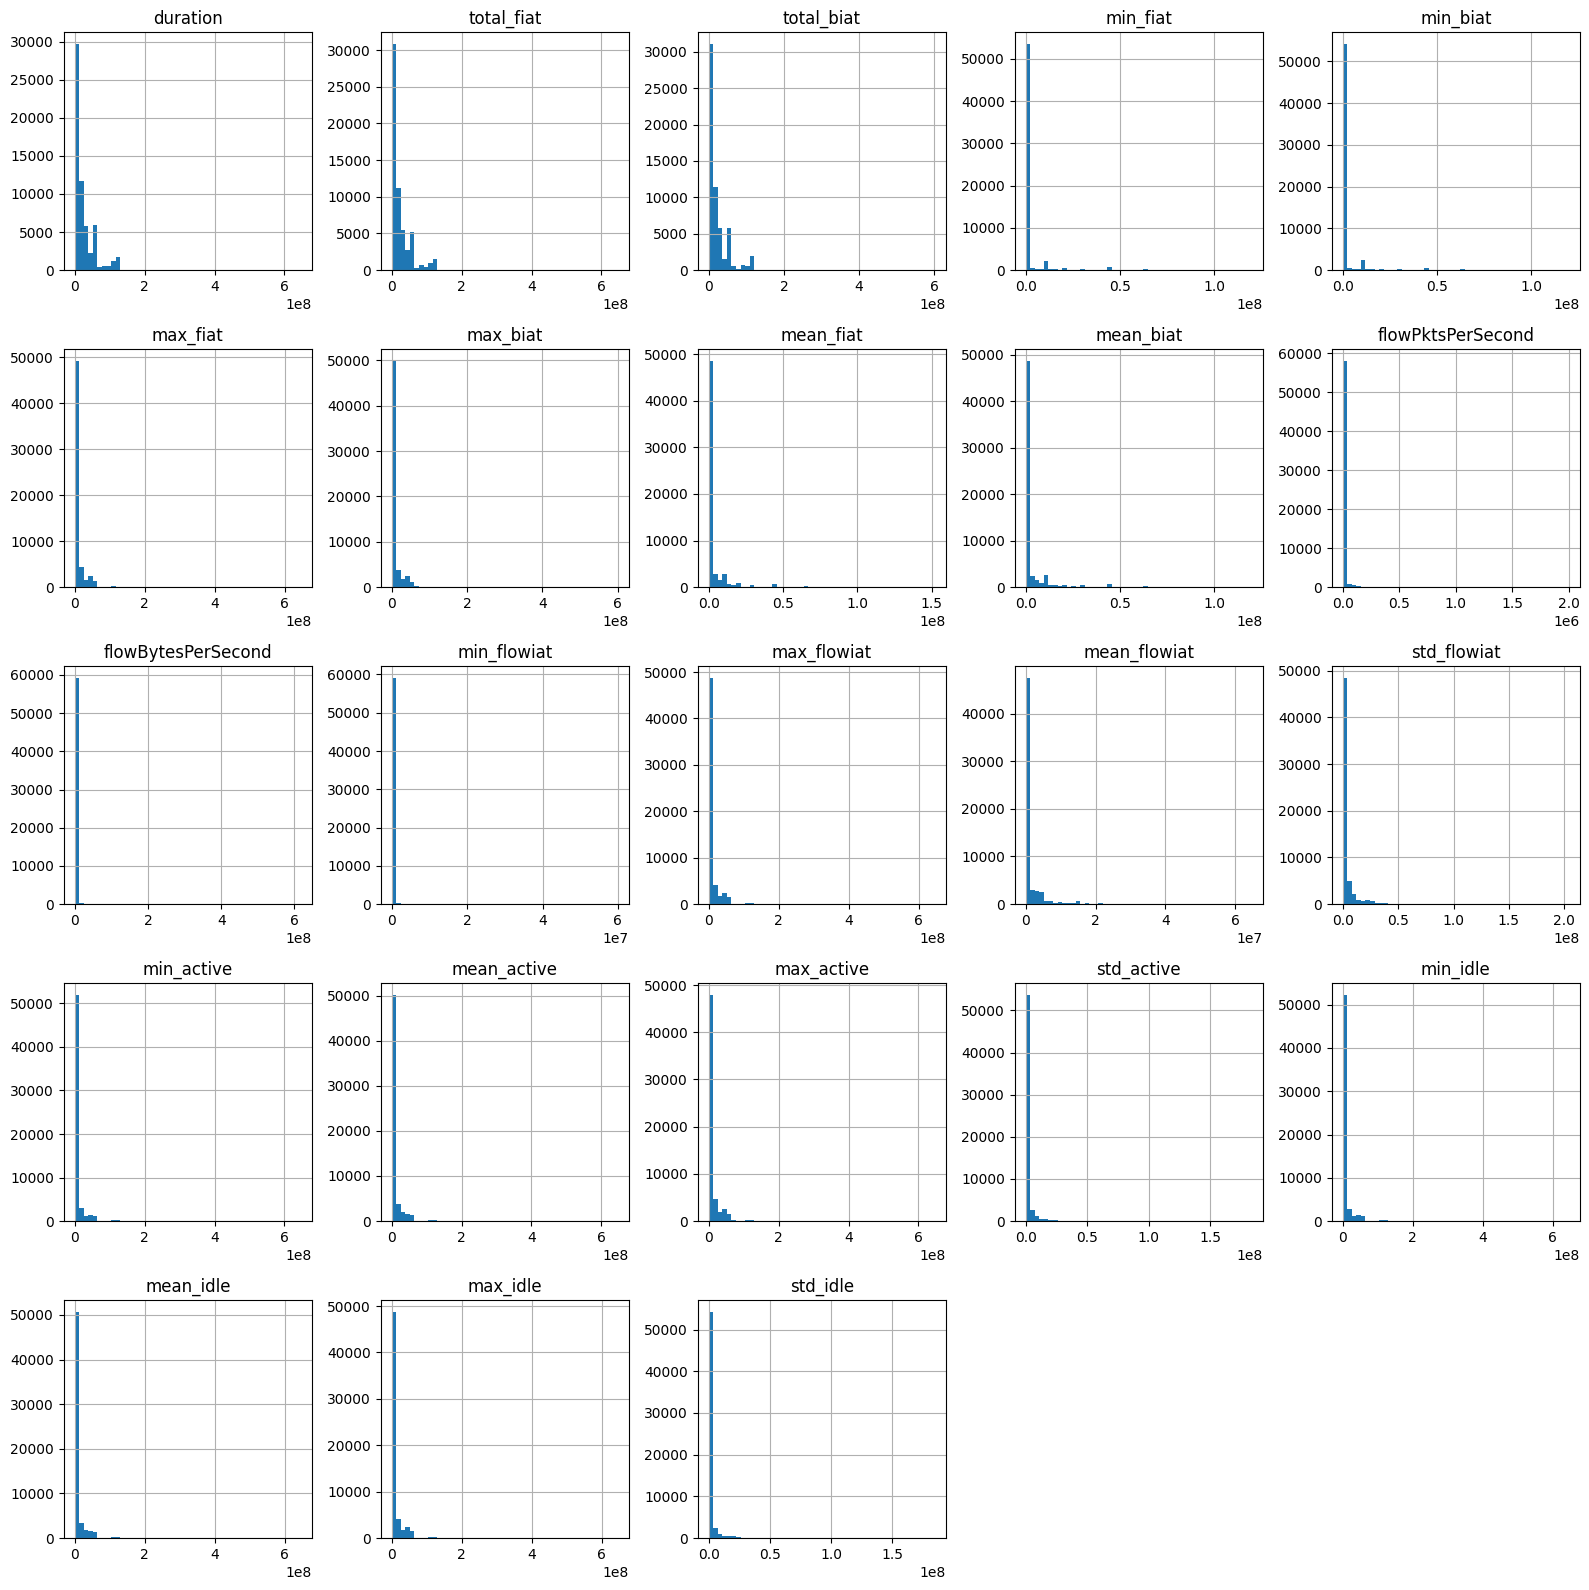

In [770]:
df[numeric_columns].hist(
    figsize=(16, 16),
    bins=50
)

plt.tight_layout()
plt.show()

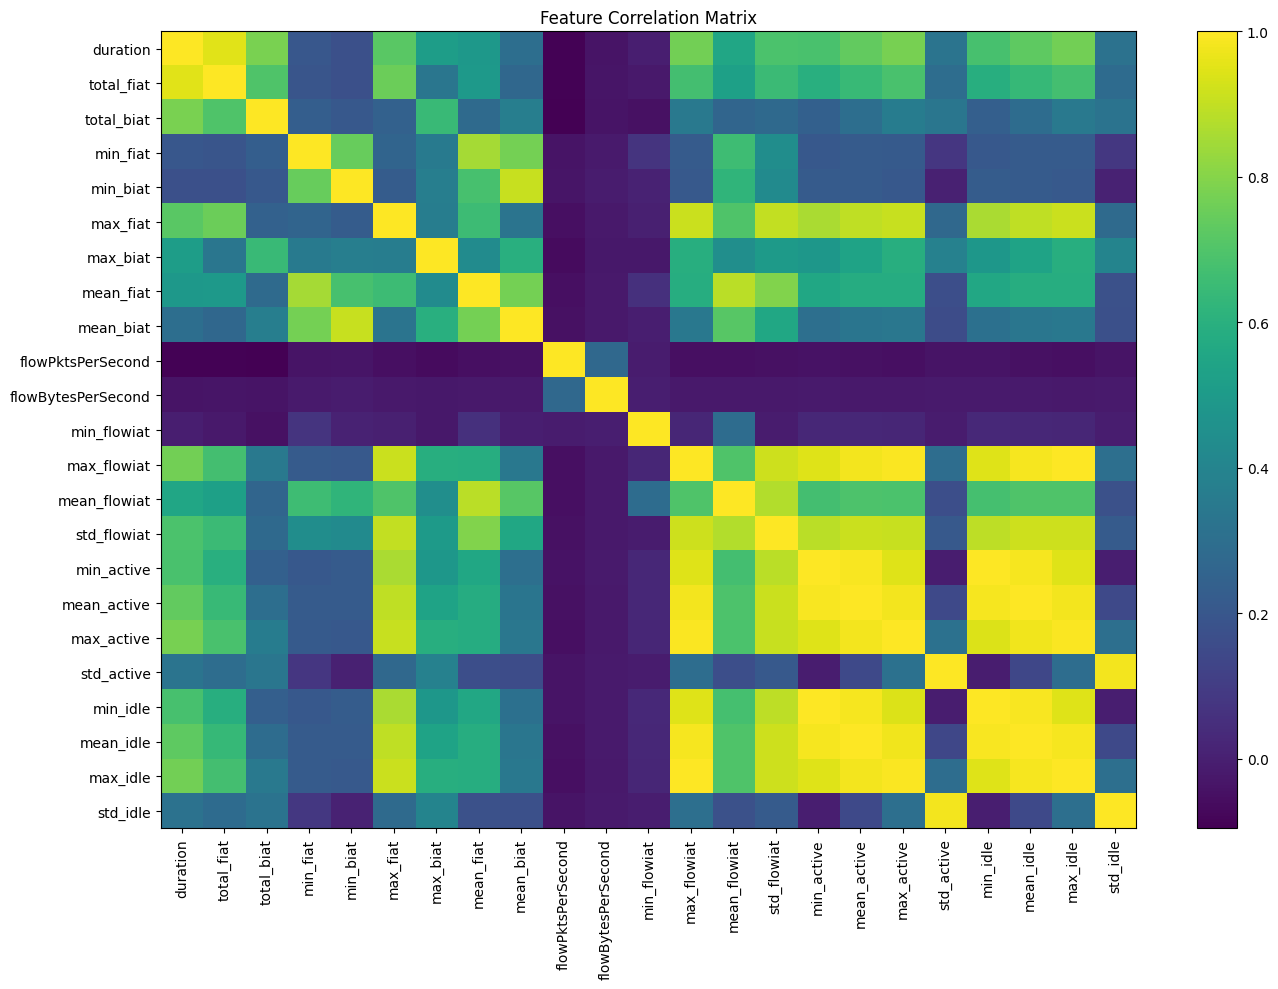

In [771]:
correlation_matrix = df[numeric_columns].corr()
plt.figure(figsize=(14, 10))

plt.imshow(correlation_matrix, aspect='auto')

plt.colorbar()

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=90
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [772]:
print("Target column:", "traffic_type")

feature_columns = [
    col for col in df.columns
    if col != "traffic_type"
]

print("Number of input features:", len(feature_columns))
print(feature_columns)

Target column: traffic_type
Number of input features: 23
['duration', 'total_fiat', 'total_biat', 'min_fiat', 'min_biat', 'max_fiat', 'max_biat', 'mean_fiat', 'mean_biat', 'flowPktsPerSecond', 'flowBytesPerSecond', 'min_flowiat', 'max_flowiat', 'mean_flowiat', 'std_flowiat', 'min_active', 'mean_active', 'max_active', 'std_active', 'min_idle', 'mean_idle', 'max_idle', 'std_idle']


Phase - 2

In [773]:
duplicate_mask = df.duplicated(keep=False)

print("Total duplicate rows:", duplicate_mask.sum())
print("Rows involved in duplicates:", duplicate_mask.sum())

duplicate_df = df[duplicate_mask]

print("\nDuplicate class distribution:")
print(duplicate_df["traffic_type"].value_counts())

Total duplicate rows: 26057
Rows involved in duplicates: 26057

Duplicate class distribution:
traffic_type
BROWSING         5159
VPN-BROWSING     4368
VPN-P2P          3226
P2P              3032
FT               2269
VPN-MAIL         2248
VPN-FT           1935
VPN-CHAT          905
MAIL              726
STREAMING         718
CHAT              568
VPN-STREAMING     402
VPN-VOIP          321
VOIP              180
Name: count, dtype: int64


In [774]:
print("\nNumber of unique duplicated records:")
print(df[duplicate_mask].drop_duplicates().shape[0])


Number of unique duplicated records:
7338


In [775]:
feature_columns = [
    col for col in df.columns
    if col != "traffic_type"
]

duplicate_groups = (
    df.groupby(feature_columns)["traffic_type"]
      .nunique()
)

conflicting_duplicates = duplicate_groups[
    duplicate_groups > 1
]

print("Duplicate feature groups with conflicting labels:",
      len(conflicting_duplicates))

Duplicate feature groups with conflicting labels: 213


In [776]:
conflicting_index = (
    df.groupby(feature_columns)["traffic_type"]
      .transform("nunique") > 1
)

conflicting_rows = df[conflicting_index]

print("Rows involved in conflicting groups:",
      len(conflicting_rows))

print("\nTraffic class distribution:")
print(conflicting_rows["traffic_type"].value_counts())

Rows involved in conflicting groups: 3635

Traffic class distribution:
traffic_type
VPN-P2P          933
FT               808
VPN-FT           596
VPN-MAIL         378
VPN-CHAT         216
VPN-BROWSING     206
MAIL             169
STREAMING        161
CHAT              54
VOIP              54
VPN-VOIP          31
BROWSING          14
P2P               13
VPN-STREAMING      2
Name: count, dtype: int64


In [777]:
conflicting_rows.sort_values(
    feature_columns
).head(20)

,duration,total_fiat,total_biat,min_fiat,min_biat,max_fiat,max_biat,mean_fiat,mean_biat,flowPktsPerSecond,...,std_flowiat,min_active,mean_active,max_active,std_active,min_idle,mean_idle,max_idle,std_idle,traffic_type
2615,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,...,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,CHAT
2665,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,...,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,CHAT
2666,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,...,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,CHAT
2721,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,...,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,CHAT
2843,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,...,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,FT
2844,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,...,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,FT
2845,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,...,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,FT
2846,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,...,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,FT
2847,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,...,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,FT
2848,0.0,0.0,0.0,-1.0,-1.0,-1.0,-1.0,0.0,0.0,0.0,...,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,-1.0,0.0,FT


In [778]:
# Keep only rows that do NOT belong to conflicting feature groups
df_clean = df[~conflicting_index].copy()

print("Original rows:", len(df))
print("Rows after removing conflicting groups:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 59706
Rows after removing conflicting groups: 56071
Rows removed: 3635


In [779]:
before_dedup = len(df_clean)

df_clean = df_clean.drop_duplicates(
    subset=feature_columns + ["traffic_type"]
).copy()

after_dedup = len(df_clean)

print("Rows before deduplication:", before_dedup)
print("Rows after deduplication:", after_dedup)
print("Duplicate rows removed:", before_dedup - after_dedup)

Rows before deduplication: 56071
Rows after deduplication: 40515
Duplicate rows removed: 15556


In [780]:
print(
    "Remaining exact duplicate rows:",
    df_clean.duplicated().sum()
)

Remaining exact duplicate rows: 0


There are no conflicting groups


In [781]:
for col in numeric_columns:

    negative = df.loc[df[col] < 0, col]

    if len(negative) > 0:

        print("\n" + "=" * 60)
        print("Feature:", col)
        print("Negative count:", len(negative))
        print("Minimum:", negative.min())
        print("Maximum:", negative.max())
        print("Unique negative values:", negative.nunique())

        print("\nMost common negative values:")
        print(negative.value_counts().head(10))


Feature: min_fiat
Negative count: 8846
Minimum: -1.0
Maximum: -1.0
Unique negative values: 1

Most common negative values:
min_fiat
-1.0    8846
Name: count, dtype: int64

Feature: min_biat
Negative count: 13857
Minimum: -1.0
Maximum: -1.0
Unique negative values: 1

Most common negative values:
min_biat
-1.0    13857
Name: count, dtype: int64

Feature: max_fiat
Negative count: 8846
Minimum: -1.0
Maximum: -1.0
Unique negative values: 1

Most common negative values:
max_fiat
-1.0    8846
Name: count, dtype: int64

Feature: max_biat
Negative count: 13857
Minimum: -1.0
Maximum: -1.0
Unique negative values: 1

Most common negative values:
max_biat
-1.0    13857
Name: count, dtype: int64

Feature: min_flowiat
Negative count: 2694
Minimum: -1247.0
Maximum: -1.0
Unique negative values: 88

Most common negative values:
min_flowiat
-1.0     2289
-2.0       57
-3.0       21
-4.0       12
-8.0       12
-39.0      12
-43.0       9
-9.0        9
-41.0       8
-28.0       8
Name: count, dtype: int64

In [782]:
negative_features = [
    'min_fiat',
    'min_biat',
    'max_fiat',
    'max_biat',
    'min_flowiat',
    'max_flowiat',
    'min_active',
    'max_active',
    'min_idle',
    'max_idle'
]

# CHANGED: apply invalid-value cleaning to the authoritative cleaned dataset.
for col in negative_features:
    df_clean.loc[df_clean[col] < 0, col] = np.nan

In [783]:
missing_counts = df_clean.isnull().sum()

print(missing_counts[missing_counts > 0])

min_fiat        3661
min_biat        5152
max_fiat        3661
max_biat        5152
min_flowiat      461
min_active     18214
max_active     18214
min_idle       18214
max_idle       18214
dtype: int64


In [784]:
print("Negative min_flowiat values:")
print(
    df.loc[df["min_flowiat"] < 0, "min_flowiat"]
      .value_counts()
      .sort_index()
)

Negative min_flowiat values:
min_flowiat
-1247.0       4
-1106.0       4
-721.0        4
-501.0        4
-489.0        4
           ... 
-5.0          8
-4.0         12
-3.0         21
-2.0         57
-1.0       2289
Name: count, Length: 88, dtype: int64


In [785]:
print("\nRows with negative min_flowiat:")
display(
    df.loc[df["min_flowiat"] < 0,
           ["min_flowiat", "traffic_type"]]
    .head(30)
)


Rows with negative min_flowiat:


,min_flowiat,traffic_type
208,-4.0,BROWSING
209,-1.0,BROWSING
213,-1.0,BROWSING
236,-5.0,BROWSING
239,-1.0,BROWSING
240,-9.0,BROWSING
248,-40.0,BROWSING
258,-32.0,BROWSING
270,-51.0,BROWSING
282,-108.0,BROWSING


In [786]:
zero_counts = (df[numeric_columns] == 0).sum()

print("Zero values per feature:")
print(zero_counts[zero_counts > 0].sort_values(ascending=False))

Zero values per feature:
std_idle              43847
std_active            43847
mean_active           32228
mean_idle             32228
total_biat            13858
mean_biat             13858
std_flowiat           10749
total_fiat             8846
mean_fiat              8846
min_flowiat            3031
duration               2110
flowPktsPerSecond      2110
mean_flowiat           2110
flowBytesPerSecond     2110
min_biat               1666
min_fiat                741
max_flowiat               2
max_biat                  1
dtype: int64


In [787]:
import os

os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(PREPROCESSING_PATH, exist_ok=True)
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs(REPORTS_PATH, exist_ok=True)

In [788]:
cleaned_path = PROCESSED_PATH + "/cleaned_traffic_data.csv"

# CHANGED: save the cleaned dataframe, not the original raw dataframe.
df_clean.to_csv(cleaned_path, index=False)

print("Cleaned dataset saved to:")
print(cleaned_path)

Cleaned dataset saved to:
/content/drive/MyDrive/VPNVision/Flow_engine/processed/cleaned_traffic_data.csv


In [789]:
# ============================================
# FINAL MODEL DATA CLEANING
# ============================================

import numpy as np

# CHANGED: train from the same cleaned dataset that is saved above.
df_model = df_clean.copy()

print("Dataset shape:", df_model.shape)

print("\nNegative values remaining:")
numeric_model_columns = df_model.select_dtypes(include="number").columns
remaining_negative = (df_model[numeric_model_columns] < 0).sum()
print(remaining_negative[remaining_negative > 0])

print("\nMissing values created:")
missing = df_model.isnull().sum()
print(missing[missing > 0])

Dataset shape: (40515, 24)

Negative values remaining:
Series([], dtype: int64)

Missing values created:
min_fiat        3661
min_biat        5152
max_fiat        3661
max_biat        5152
min_flowiat      461
min_active     18214
max_active     18214
min_idle       18214
max_idle       18214
dtype: int64


In [790]:
from sklearn.model_selection import train_test_split

# Separate features and target
X = df_model.drop(columns=["traffic_type"])
y = df_model["traffic_type"]

# 70% train, 15% validation, 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("TRAIN:", X_train.shape)
print("VALIDATION:", X_val.shape)
print("TEST:", X_test.shape)

TRAIN: (28360, 23)
VALIDATION: (6077, 23)
TEST: (6078, 23)


In [791]:
train_df = X_train.copy()
train_df["traffic_type"] = y_train

val_df = X_val.copy()
val_df["traffic_type"] = y_val

test_df = X_test.copy()
test_df["traffic_type"] = y_test

In [792]:
print("TRAIN missing:")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

print("\nVALIDATION missing:")
print(val_df.isnull().sum()[val_df.isnull().sum() > 0])

print("\nTEST missing:")
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])

TRAIN missing:
min_fiat        2599
min_biat        3611
max_fiat        2599
max_biat        3611
min_flowiat      340
min_active     12778
max_active     12778
min_idle       12778
max_idle       12778
dtype: int64

VALIDATION missing:
min_fiat        528
min_biat        785
max_fiat        528
max_biat        785
min_flowiat      53
min_active     2699
max_active     2699
min_idle       2699
max_idle       2699
dtype: int64

TEST missing:
min_fiat        534
min_biat        756
max_fiat        534
max_biat        756
min_flowiat      68
min_active     2737
max_active     2737
min_idle       2737
max_idle       2737
dtype: int64


In [793]:
# ============================================
# HANDLE MISSING VALUES
# ============================================

print("Missing values before imputation:")

print("TRAIN:")
print(train_df[impute_features].isna().sum())

print("\nVALIDATION:")
print(val_df[impute_features].isna().sum())

print("\nTEST:")
print(test_df[impute_features].isna().sum())

Missing values before imputation:
TRAIN:
min_fiat        2599
min_biat        3611
max_fiat        2599
max_biat        3611
min_flowiat      340
min_active     12778
max_active     12778
min_idle       12778
max_idle       12778
dtype: int64

VALIDATION:
min_fiat        528
min_biat        785
max_fiat        528
max_biat        785
min_flowiat      53
min_active     2699
max_active     2699
min_idle       2699
max_idle       2699
dtype: int64

TEST:
min_fiat        534
min_biat        756
max_fiat        534
max_biat        756
min_flowiat      68
min_active     2737
max_active     2737
min_idle       2737
max_idle       2737
dtype: int64


In [794]:
train_medians = train_df[impute_features].median()

print("Training-set imputation values:")
print(train_medians)

Training-set imputation values:
min_fiat            113.0
min_biat             50.0
max_fiat        3846121.0
max_biat        4074743.0
min_flowiat          20.0
min_active      5043538.5
max_active     10288415.0
min_idle        4371688.0
max_idle       10000651.0
dtype: float64


In [795]:
train_df[impute_features] = train_df[impute_features].fillna(train_medians)
val_df[impute_features] = val_df[impute_features].fillna(train_medians)
test_df[impute_features] = test_df[impute_features].fillna(train_medians)

In [796]:
train_medians

,0
min_fiat,113.0
min_biat,50.0
max_fiat,3846121.0
max_biat,4074743.0
min_flowiat,20.0
min_active,5043538.5
max_active,10288415.0
min_idle,4371688.0
max_idle,10000651.0


In [797]:
print("TRAIN missing:")
print(train_df.isnull().sum()[train_df.isnull().sum() > 0])

print("\nVALIDATION missing:")
print(val_df.isnull().sum()[val_df.isnull().sum() > 0])

print("\nTEST missing:")
print(test_df.isnull().sum()[test_df.isnull().sum() > 0])

TRAIN missing:
Series([], dtype: int64)

VALIDATION missing:
Series([], dtype: int64)

TEST missing:
Series([], dtype: int64)


In [798]:
numeric_features = train_df.select_dtypes(include=["number"]).columns

print("TRAIN negative values:")
print((train_df[numeric_features] < 0).sum()[
    (train_df[numeric_features] < 0).sum() > 0
])

print("\nVALIDATION negative values:")
print((val_df[numeric_features] < 0).sum()[
    (val_df[numeric_features] < 0).sum() > 0
])

print("\nTEST negative values:")
print((test_df[numeric_features] < 0).sum()[
    (test_df[numeric_features] < 0).sum() > 0
])

TRAIN negative values:
Series([], dtype: int64)

VALIDATION negative values:
Series([], dtype: int64)

TEST negative values:
Series([], dtype: int64)


In [799]:
print("Train duplicates:", train_df.duplicated().sum())
print("Validation duplicates:", val_df.duplicated().sum())
print("Test duplicates:", test_df.duplicated().sum())

Train duplicates: 0
Validation duplicates: 0
Test duplicates: 0


In [800]:
# ============================================
# ORIGINAL 23 FLOW FEATURES
# ============================================

feature_columns = [
    col for col in df.columns
    if col != "traffic_type"
]

print("Number of traffic classification features:",
      len(feature_columns))

print(feature_columns)

Number of traffic classification features: 23
['duration', 'total_fiat', 'total_biat', 'min_fiat', 'min_biat', 'max_fiat', 'max_biat', 'mean_fiat', 'mean_biat', 'flowPktsPerSecond', 'flowBytesPerSecond', 'min_flowiat', 'max_flowiat', 'mean_flowiat', 'std_flowiat', 'min_active', 'mean_active', 'max_active', 'std_active', 'min_idle', 'mean_idle', 'max_idle', 'std_idle']


In [801]:
print("========== FINAL CLEANING CHECK ==========")

print("\nShapes:")
print("TRAIN:", train_df.shape)
print("VALIDATION:", val_df.shape)
print("TEST:", test_df.shape)

print("\nMissing values:")
print("TRAIN:", train_df.isnull().sum().sum())
print("VALIDATION:", val_df.isnull().sum().sum())
print("TEST:", test_df.isnull().sum().sum())

numeric_cols = train_df.select_dtypes(include="number").columns

print("\nNegative values:")
print("TRAIN:", (train_df[numeric_cols] < 0).sum().sum())
print("VALIDATION:", (val_df[numeric_cols] < 0).sum().sum())
print("TEST:", (test_df[numeric_cols] < 0).sum().sum())

print("\nExact duplicates:")
print("TRAIN:", train_df.duplicated().sum())
print("VALIDATION:", val_df.duplicated().sum())
print("TEST:", test_df.duplicated().sum())

print("\nTraffic classes:")
print(train_df["traffic_type"].value_counts())

========== FINAL CLEANING CHECK ==========

Shapes:
TRAIN: (28360, 24)
VALIDATION: (6077, 24)
TEST: (6078, 24)

Missing values:
TRAIN: 0
VALIDATION: 0
TEST: 0

Negative values:
TRAIN: 0
VALIDATION: 0
TEST: 0

Exact duplicates:
TRAIN: 0
VALIDATION: 0
TEST: 0

Traffic classes:
traffic_type
VPN-BROWSING     5077
BROWSING         4514
VOIP             4437
VPN-VOIP         3733
VPN-FT           2239
VPN-CHAT         1510
CHAT             1480
FT               1420
P2P              1364
VPN-STREAMING     584
VPN-P2P           553
MAIL              549
STREAMING         517
VPN-MAIL          383
Name: count, dtype: int64


In [802]:
# ============================================
# SEPARATE 23 FEATURES AND TARGET
# ============================================

X_train = train_df[feature_columns].copy()
y_train = train_df["traffic_type"].copy()

X_val = val_df[feature_columns].copy()
y_val = val_df["traffic_type"].copy()

X_test = test_df[feature_columns].copy()
y_test = test_df["traffic_type"].copy()

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

print("\nNumber of features:", len(feature_columns))
print("\nFeature columns:")
print(feature_columns)

X_train: (28360, 23)
y_train: (28360,)
X_val: (6077, 23)
y_val: (6077,)
X_test: (6078, 23)
y_test: (6078,)

Number of features: 23

Feature columns:
['duration', 'total_fiat', 'total_biat', 'min_fiat', 'min_biat', 'max_fiat', 'max_biat', 'mean_fiat', 'mean_biat', 'flowPktsPerSecond', 'flowBytesPerSecond', 'min_flowiat', 'max_flowiat', 'mean_flowiat', 'std_flowiat', 'min_active', 'mean_active', 'max_active', 'std_active', 'min_idle', 'mean_idle', 'max_idle', 'std_idle']


In [803]:
print("Non-numeric columns:")
print(X_train.select_dtypes(exclude="number").columns.tolist())

print("\nData types:")
print(X_train.dtypes)

Non-numeric columns:
[]

Data types:
duration              float64
total_fiat            float64
total_biat            float64
min_fiat              float64
min_biat              float64
max_fiat              float64
max_biat              float64
mean_fiat             float64
mean_biat             float64
flowPktsPerSecond     float64
flowBytesPerSecond    float64
min_flowiat           float64
max_flowiat           float64
mean_flowiat          float64
std_flowiat           float64
min_active            float64
mean_active           float64
max_active            float64
std_active            float64
min_idle              float64
mean_idle             float64
max_idle              float64
std_idle              float64
dtype: object


In [804]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

print("Traffic class mapping:")
for i, class_name in enumerate(label_encoder.classes_):
    print(i, "=", class_name)

Traffic class mapping:
0 = BROWSING
1 = CHAT
2 = FT
3 = MAIL
4 = P2P
5 = STREAMING
6 = VOIP
7 = VPN-BROWSING
8 = VPN-CHAT
9 = VPN-FT
10 = VPN-MAIL
11 = VPN-P2P
12 = VPN-STREAMING
13 = VPN-VOIP


In [805]:
print("\nTRAIN:")
print(pd.Series(y_train_encoded).value_counts().sort_index())

print("\nVALIDATION:")
print(pd.Series(y_val_encoded).value_counts().sort_index())

print("\nTEST:")
print(pd.Series(y_test_encoded).value_counts().sort_index())


TRAIN:
0     4514
1     1480
2     1420
3      549
4     1364
5      517
6     4437
7     5077
8     1510
9     2239
10     383
11     553
12     584
13    3733
Name: count, dtype: int64

VALIDATION:
0      967
1      317
2      304
3      118
4      293
5      111
6      950
7     1088
8      323
9      480
10      82
11     119
12     125
13     800
Name: count, dtype: int64

TEST:
0      968
1      318
2      304
3      117
4      292
5      111
6      951
7     1088
8      324
9      480
10      82
11     118
12     125
13     800
Name: count, dtype: int64


In [806]:
print("Train columns == Validation columns:",
      list(X_train.columns) == list(X_val.columns))

print("Train columns == Test columns:",
      list(X_train.columns) == list(X_test.columns))

Train columns == Validation columns: True
Train columns == Test columns: True


In [807]:
print("Target present in X_train:", "traffic_type" in X_train.columns)

Target present in X_train: False


Model training - Traffic Classifier

In [808]:
from xgboost import XGBClassifier

# Create XGBoost traffic classifier
xgb_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(label_encoder.classes_),
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1
)

print("XGBoost model created successfully.")

XGBoost model created successfully.


In [809]:
xgb_model.fit(
    X_train,
    y_train_encoded,
    eval_set=[
        (X_train, y_train_encoded),
        (X_val, y_val_encoded)
    ],
    verbose=True
)

print("Training completed.")

[0]	validation_0-mlogloss:2.13881	validation_1-mlogloss:2.14628
[1]	validation_0-mlogloss:2.00064	validation_1-mlogloss:2.01362
[2]	validation_0-mlogloss:1.88404	validation_1-mlogloss:1.90282
[3]	validation_0-mlogloss:1.78351	validation_1-mlogloss:1.80749
[4]	validation_0-mlogloss:1.69538	validation_1-mlogloss:1.72470
[5]	validation_0-mlogloss:1.61578	validation_1-mlogloss:1.64914
[6]	validation_0-mlogloss:1.54283	validation_1-mlogloss:1.58069
[7]	validation_0-mlogloss:1.47681	validation_1-mlogloss:1.51914
[8]	validation_0-mlogloss:1.41706	validation_1-mlogloss:1.46260
[9]	validation_0-mlogloss:1.36498	validation_1-mlogloss:1.41391
[10]	validation_0-mlogloss:1.31300	validation_1-mlogloss:1.36481
[11]	validation_0-mlogloss:1.26427	validation_1-mlogloss:1.31936
[12]	validation_0-mlogloss:1.21809	validation_1-mlogloss:1.27608
[13]	validation_0-mlogloss:1.17534	validation_1-mlogloss:1.23627
[14]	validation_0-mlogloss:1.13746	validation_1-mlogloss:1.20098
[15]	validation_0-mlogloss:1.10006	

In [810]:
import numpy as np

# Get probabilities for all 14 classes
test_proba = xgb_model.predict_proba(X_test)

# Get Top-3 class indices for every test sample
top3_indices = np.argsort(test_proba, axis=1)[:, -3:][:, ::-1]

print("========== TOP-3 XGBOOST PREDICTIONS ==========\n")

for i in range(20):

    print(f"Flow {i + 1}")
    print("-" * 40)

    for rank, class_index in enumerate(top3_indices[i], start=1):

        class_name = label_encoder.inverse_transform(
            [class_index]
        )[0]

        confidence = test_proba[i, class_index] * 100

        print(
            f"{rank}. {class_name:<15} "
            f"{confidence:.2f}%"
        )

    print()

========== TOP-3 XGBOOST PREDICTIONS ==========

Flow 1
----------------------------------------
1. P2P             98.17%
2. VPN-VOIP        0.62%
3. VPN-FT          0.45%

Flow 2
----------------------------------------
1. VPN-VOIP        99.63%
2. BROWSING        0.12%
3. VOIP            0.11%

Flow 3
----------------------------------------
1. BROWSING        96.04%
2. VPN-BROWSING    2.90%
3. VPN-FT          0.37%

Flow 4
----------------------------------------
1. BROWSING        97.69%
2. VPN-BROWSING    1.47%
3. STREAMING       0.70%

Flow 5
----------------------------------------
1. VPN-STREAMING   96.29%
2. BROWSING        1.91%
3. VPN-BROWSING    1.08%

Flow 6
----------------------------------------
1. VPN-VOIP        99.79%
2. BROWSING        0.07%
3. VOIP            0.06%

Flow 7
----------------------------------------
1. CHAT            93.60%
2. VPN-FT          3.90%
3. VPN-BROWSING    1.56%

Flow 8
----------------------------------------
1. VPN-VOIP        92.58%
2.

In [811]:
results = []

for i in range(len(X_test)):

    # Top-3 class indices
    indices = top3_indices[i]

    # Top-1
    class1 = label_encoder.inverse_transform([indices[0]])[0]
    conf1 = test_proba[i, indices[0]] * 100

    # Top-2
    class2 = label_encoder.inverse_transform([indices[1]])[0]
    conf2 = test_proba[i, indices[1]] * 100

    # Top-3
    class3 = label_encoder.inverse_transform([indices[2]])[0]
    conf3 = test_proba[i, indices[2]] * 100

    results.append({
        "predicted_traffic": class1,
        "confidence": conf1,

        "top2_traffic": class2,
        "top2_confidence": conf2,

        "top3_traffic": class3,
        "top3_confidence": conf3
    })

xgb_results = pd.DataFrame(results)

print(xgb_results.head(10))

  predicted_traffic  confidence  top2_traffic  top2_confidence  top3_traffic  \
0               P2P   98.166718      VPN-VOIP         0.618193        VPN-FT   
1          VPN-VOIP   99.632782      BROWSING         0.121005          VOIP   
2          BROWSING   96.036842  VPN-BROWSING         2.901925        VPN-FT   
3          BROWSING   97.692787  VPN-BROWSING         1.474159     STREAMING   
4     VPN-STREAMING   96.292976      BROWSING         1.914841  VPN-BROWSING   
5          VPN-VOIP   99.786781      BROWSING         0.069266          VOIP   
6              CHAT   93.600410        VPN-FT         3.898618  VPN-BROWSING   
7          VPN-VOIP   92.581223        VPN-FT         5.498373  VPN-BROWSING   
8          BROWSING   69.546066          CHAT        15.502432  VPN-BROWSING   
9      VPN-BROWSING   41.539452      BROWSING        38.953190        VPN-FT   

   top3_confidence  
0         0.451916  
1         0.107399  
2         0.367701  
3         0.700085  
4         1.07

In [812]:
def classify_traffic_top3(model, X, label_encoder):

    # Get probabilities
    probabilities = model.predict_proba(X)

    # Get top 3 classes
    top3_indices = np.argsort(
        probabilities,
        axis=1
    )[:, -3:][:, ::-1]

    results = []

    for i in range(len(X)):

        predictions = []

        for rank, class_index in enumerate(
            top3_indices[i],
            start=1
        ):

            class_name = label_encoder.inverse_transform(
                [class_index]
            )[0]

            confidence = probabilities[
                i, class_index
            ] * 100

            predictions.append({
                "rank": rank,
                "traffic_type": class_name,
                "confidence": round(confidence, 2)
            })

        results.append(predictions)

    return results

In [813]:
y_val_pred = xgb_model.predict(X_val)
y_val_proba = xgb_model.predict_proba(X_val)

print("Validation predictions generated.")
print("Prediction shape:", y_val_pred.shape)
print("Probability shape:", y_val_proba.shape)

Validation predictions generated.
Prediction shape: (6077,)
Probability shape: (6077, 14)


In [814]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

accuracy = accuracy_score(y_val_encoded, y_val_pred)

precision = precision_score(
    y_val_encoded,
    y_val_pred,
    average="macro",
    zero_division=0
)

recall = recall_score(
    y_val_encoded,
    y_val_pred,
    average="macro",
    zero_division=0
)

f1 = f1_score(
    y_val_encoded,
    y_val_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_val_encoded,
    y_val_pred,
    average="weighted",
    zero_division=0
)

print("========== VALIDATION RESULTS ==========")
print(f"Accuracy       : {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall   : {recall:.4f}")
print(f"Macro F1       : {f1:.4f}")
print(f"Weighted F1    : {weighted_f1:.4f}")

========== VALIDATION RESULTS ==========
Accuracy       : 0.8980
Macro Precision: 0.8889
Macro Recall   : 0.8537
Macro F1       : 0.8696
Weighted F1    : 0.8975


In [815]:
print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        y_val_encoded,
        y_val_pred,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)


========== CLASSIFICATION REPORT ==========
               precision    recall  f1-score   support

     BROWSING     0.8617    0.9018    0.8813       967
         CHAT     0.8365    0.8233    0.8299       317
           FT     0.9283    0.8947    0.9112       304
         MAIL     0.8839    0.8390    0.8609       118
          P2P     0.9231    0.9420    0.9324       293
    STREAMING     0.8776    0.7748    0.8230       111
         VOIP     0.9872    0.9779    0.9825       950
 VPN-BROWSING     0.8599    0.9026    0.8807      1088
     VPN-CHAT     0.8333    0.7740    0.8026       323
       VPN-FT     0.8484    0.8625    0.8554       480
     VPN-MAIL     0.9265    0.7683    0.8400        82
      VPN-P2P     0.7895    0.6303    0.7009       119
VPN-STREAMING     0.9262    0.9040    0.9150       125
     VPN-VOIP     0.9623    0.9563    0.9592       800

     accuracy                         0.8980      6077
    macro avg     0.8889    0.8537    0.8696      6077
 weighted avg     

In [816]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_test_pred = xgb_model.predict(X_test)

xgb_test_accuracy = accuracy_score(
    y_test_encoded,
    y_test_pred
)

xgb_test_precision = precision_score(
    y_test_encoded,
    y_test_pred,
    average="macro",
    zero_division=0
)

xgb_test_recall = recall_score(
    y_test_encoded,
    y_test_pred,
    average="macro",
    zero_division=0
)

xgb_test_f1 = f1_score(
    y_test_encoded,
    y_test_pred,
    average="macro",
    zero_division=0
)

xgb_test_weighted_f1 = f1_score(
    y_test_encoded,
    y_test_pred,
    average="weighted",
    zero_division=0
)

print("============================================")
print("XGBOOST FINAL TEST EVALUATION")
print("============================================")

print(f"Accuracy        : {xgb_test_accuracy:.4f}")
print(f"Macro Precision : {xgb_test_precision:.4f}")
print(f"Macro Recall    : {xgb_test_recall:.4f}")
print(f"Macro F1        : {xgb_test_f1:.4f}")
print(f"Weighted F1     : {xgb_test_weighted_f1:.4f}")

XGBOOST FINAL TEST EVALUATION
Accuracy        : 0.8949
Macro Precision : 0.8727
Macro Recall    : 0.8461
Macro F1        : 0.8579
Weighted F1     : 0.8943


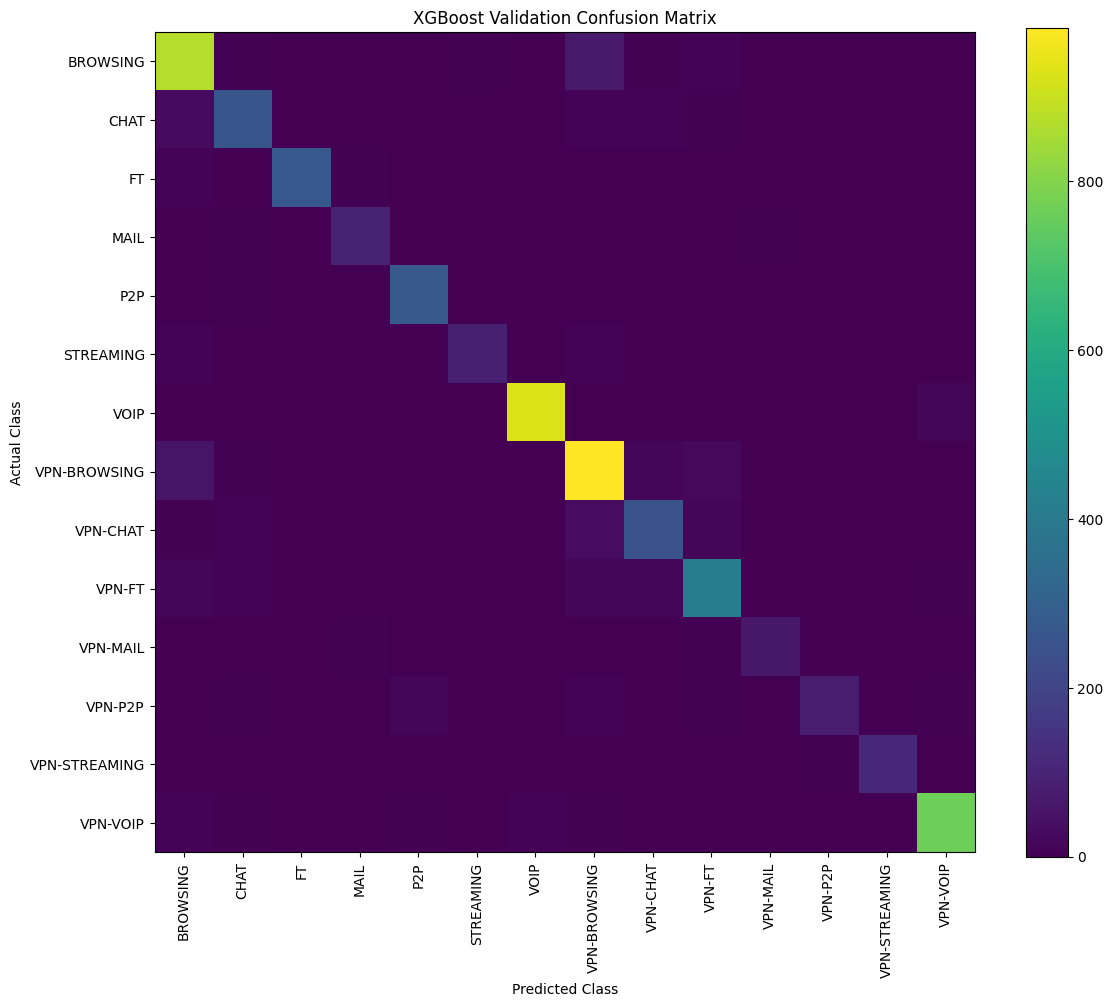

In [817]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_val_encoded,
    y_val_pred
)

plt.figure(figsize=(12, 10))

plt.imshow(cm)

plt.title("XGBoost Validation Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.colorbar()

plt.tight_layout()
plt.show()

In [818]:
y_test_pred = xgb_model.predict(X_test)

print(
    classification_report(
        y_test_encoded,
        y_test_pred,
        target_names=label_encoder.classes_,
        digits=4,
        zero_division=0
    )
)

               precision    recall  f1-score   support

     BROWSING     0.8630    0.9112    0.8864       968
         CHAT     0.8162    0.8239    0.8200       318
           FT     0.9462    0.8684    0.9057       304
         MAIL     0.8067    0.8205    0.8136       117
          P2P     0.9037    0.9315    0.9174       292
    STREAMING     0.8750    0.7568    0.8116       111
         VOIP     0.9851    0.9716    0.9783       951
 VPN-BROWSING     0.8687    0.8879    0.8782      1088
     VPN-CHAT     0.8616    0.7685    0.8124       324
       VPN-FT     0.8277    0.8708    0.8487       480
     VPN-MAIL     0.8235    0.6829    0.7467        82
      VPN-P2P     0.7300    0.6186    0.6697       118
VPN-STREAMING     0.9453    0.9680    0.9565       125
     VPN-VOIP     0.9650    0.9650    0.9650       800

     accuracy                         0.8949      6078
    macro avg     0.8727    0.8461    0.8579      6078
 weighted avg     0.8951    0.8949    0.8943      6078



In [819]:
import os
import joblib

MODEL_DIR = "/content/drive/MyDrive/VPNVision/Flow_engine/models"

os.makedirs(MODEL_DIR, exist_ok=True)

# Save XGBoost model
xgb_model.save_model(
    MODEL_DIR + "/xgboost_traffic_classifier.json"
)

# Save label encoder
joblib.dump(
    label_encoder,
    MODEL_DIR + "/label_encoder.pkl"
)

# Save feature names
joblib.dump(
    feature_columns,
    MODEL_DIR + "/feature_names.pkl"
)

print("XGBoost model and supporting files saved successfully.")

XGBoost model and supporting files saved successfully.


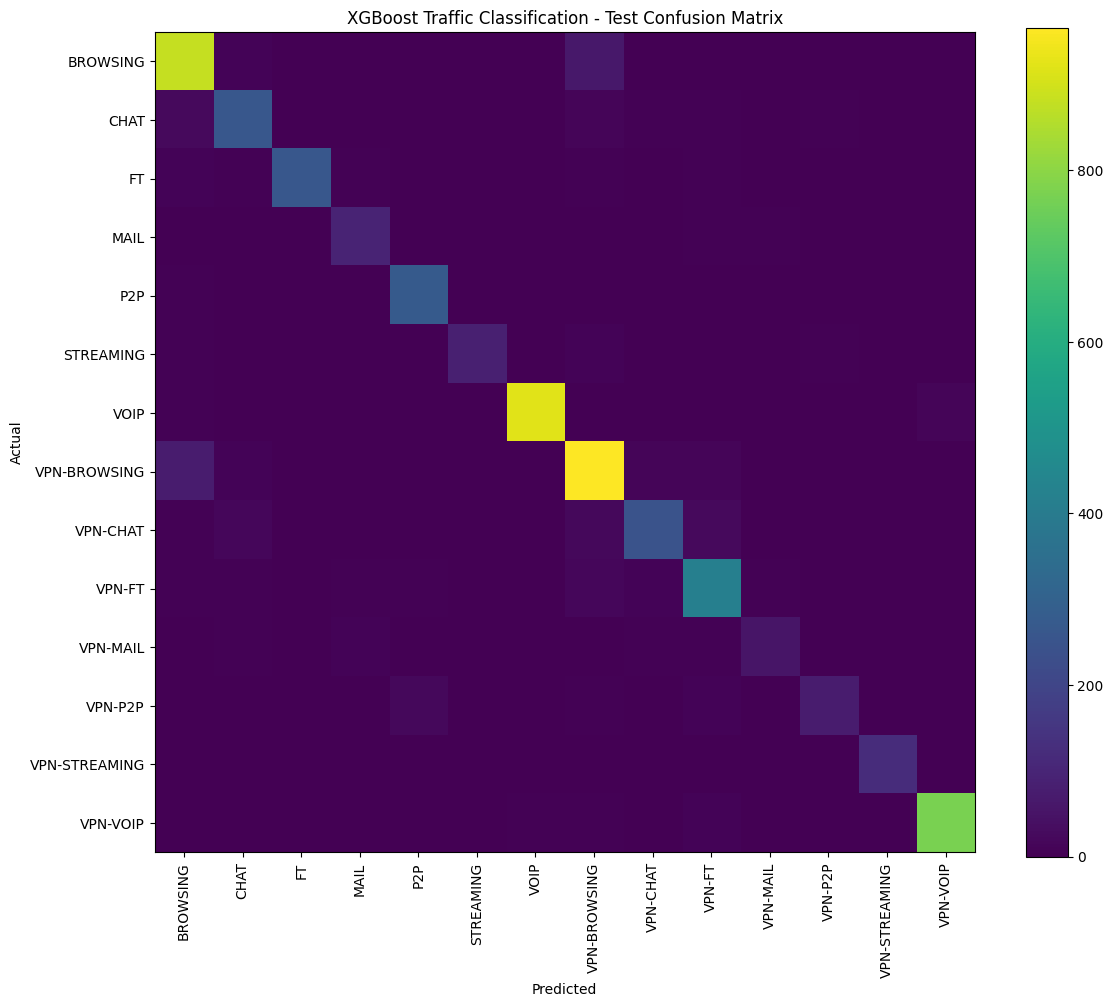

In [820]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# XGBoost predictions
y_test_pred = xgb_model.predict(X_test)

# Convert prediction to integer if necessary
y_test_pred = y_test_pred.astype(int)

# Convert numeric predictions back to traffic names
y_test_pred_labels = label_encoder.inverse_transform(y_test_pred)

# Confusion matrix using string labels on both sides
cm = confusion_matrix(y_test, y_test_pred_labels)

# Plot
plt.figure(figsize=(12, 10))
plt.imshow(cm)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Traffic Classification - Test Confusion Matrix")
plt.colorbar()

plt.xticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_,
    rotation=90
)

plt.yticks(
    range(len(label_encoder.classes_)),
    label_encoder.classes_
)

plt.tight_layout()
plt.show()

In [821]:
print("y_test type:", type(y_test.iloc[0]))
print("prediction type:", type(y_test_pred[0]))

print("\nFirst 10 actual:")
print(y_test.iloc[:10].values)

print("\nFirst 10 predicted:")
print(y_test_pred_labels[:10])

y_test type: <class 'str'>
prediction type: <class 'numpy.int64'>

First 10 actual:
['P2P' 'VPN-VOIP' 'BROWSING' 'BROWSING' 'VPN-STREAMING' 'VPN-VOIP' 'CHAT'
 'VPN-VOIP' 'BROWSING' 'VPN-BROWSING']

First 10 predicted:
['P2P' 'VPN-VOIP' 'BROWSING' 'BROWSING' 'VPN-STREAMING' 'VPN-VOIP' 'CHAT'
 'VPN-VOIP' 'BROWSING' 'VPN-BROWSING']


Anomoly Detection - Isolation Forest

In [822]:
import numpy as np
import pandas as pd
import joblib

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler

In [823]:
features = [
    "duration",
    "total_fiat",
    "total_biat",
    "min_fiat",
    "min_biat",
    "max_fiat",
    "max_biat",
    "mean_fiat",
    "mean_biat",
    "flowPktsPerSecond",
    "flowBytesPerSecond",
    "min_flowiat",
    "max_flowiat",
    "mean_flowiat",
    "std_flowiat",
    "min_active",
    "mean_active",
    "max_active",
    "std_active",
    "min_idle",
    "mean_idle",
    "max_idle",
    "std_idle"
]

print("Number of Isolation Forest features:", len(features))
print(features)

Number of Isolation Forest features: 23
['duration', 'total_fiat', 'total_biat', 'min_fiat', 'min_biat', 'max_fiat', 'max_biat', 'mean_fiat', 'mean_biat', 'flowPktsPerSecond', 'flowBytesPerSecond', 'min_flowiat', 'max_flowiat', 'mean_flowiat', 'std_flowiat', 'min_active', 'mean_active', 'max_active', 'std_active', 'min_idle', 'mean_idle', 'max_idle', 'std_idle']


In [824]:
# ============================================
# ISOLATION FOREST INPUT DATA
# ============================================

X_if_train = X_train[features].copy()
X_if_val = X_val[features].copy()
X_if_test = X_test[features].copy()

print("X_if_train:", X_if_train.shape)
print("X_if_val  :", X_if_val.shape)
print("X_if_test :", X_if_test.shape)

print("\nIsolation Forest feature count:",
      X_if_train.shape[1])

X_if_train: (28360, 23)
X_if_val  : (6077, 23)
X_if_test : (6078, 23)

Isolation Forest feature count: 23


In [825]:
print("Isolation Forest features:")
print(X_if_train.columns.tolist())

print("\nNumber of features:", X_if_train.shape[1])

print("\nNon-numeric columns:")
print(X_if_train.select_dtypes(exclude=np.number).columns.tolist())

print("\nTarget present:",
      "traffic_type" in X_if_train.columns)

Isolation Forest features:
['duration', 'total_fiat', 'total_biat', 'min_fiat', 'min_biat', 'max_fiat', 'max_biat', 'mean_fiat', 'mean_biat', 'flowPktsPerSecond', 'flowBytesPerSecond', 'min_flowiat', 'max_flowiat', 'mean_flowiat', 'std_flowiat', 'min_active', 'mean_active', 'max_active', 'std_active', 'min_idle', 'mean_idle', 'max_idle', 'std_idle']

Number of features: 23

Non-numeric columns:
[]

Target present: False


In [826]:
print("========== ISOLATION FOREST DATA CHECK ==========")

print("\nMissing values:")
print("Train:", X_if_train.isna().sum().sum())
print("Validation:", X_if_val.isna().sum().sum())
print("Test:", X_if_test.isna().sum().sum())

print("\nInfinite values:")
print("Train:", np.isinf(X_if_train).sum().sum())
print("Validation:", np.isinf(X_if_val).sum().sum())
print("Test:", np.isinf(X_if_test).sum().sum())

print("\nNegative values:")
print("Train:", (X_if_train < 0).sum().sum())
print("Validation:", (X_if_val < 0).sum().sum())
print("Test:", (X_if_test < 0).sum().sum())

========== ISOLATION FOREST DATA CHECK ==========

Missing values:
Train: 0
Validation: 0
Test: 0

Infinite values:
Train: 0
Validation: 0
Test: 0

Negative values:
Train: 0
Validation: 0
Test: 0


In [827]:
scaler_if = RobustScaler()

X_if_train_scaled = scaler_if.fit_transform(X_if_train)

X_if_val_scaled = scaler_if.transform(X_if_val)

X_if_test_scaled = scaler_if.transform(X_if_test)

print("Scaled train shape:", X_if_train_scaled.shape)
print("Scaled validation shape:", X_if_val_scaled.shape)
print("Scaled test shape:", X_if_test_scaled.shape)

Scaled train shape: (28360, 23)
Scaled validation shape: (6077, 23)
Scaled test shape: (6078, 23)


In [828]:
# ============================================
# ISOLATION FOREST MODEL TRAINING
# ============================================

from sklearn.ensemble import IsolationForest

isolation_forest = IsolationForest(
    n_estimators=200,
    contamination=0.10,
    random_state=42,
    n_jobs=-1
)

isolation_forest.fit(X_if_train_scaled)

print("Isolation Forest fitted successfully.")

Isolation Forest fitted successfully.


In [829]:
train_predictions = isolation_forest.predict(X_if_train_scaled)
val_predictions = isolation_forest.predict(X_if_val_scaled)
test_predictions = isolation_forest.predict(X_if_test_scaled)

print("TRAIN")
print(pd.Series(train_predictions).value_counts())

print("\nVALIDATION")
print(pd.Series(val_predictions).value_counts())

print("\nTEST")
print(pd.Series(test_predictions).value_counts())

TRAIN
 1    25524
-1     2836
Name: count, dtype: int64

VALIDATION
 1    5459
-1     618
Name: count, dtype: int64

TEST
 1    5490
-1     588
Name: count, dtype: int64


In [830]:
# ============================================
# ISOLATION FOREST RAW SCORES
# ============================================

train_raw_scores = isolation_forest.score_samples(
    X_if_train_scaled
)

val_raw_scores = isolation_forest.score_samples(
    X_if_val_scaled
)

test_raw_scores = isolation_forest.score_samples(
    X_if_test_scaled
)

print("Raw scores calculated successfully.")

print("Train:", len(train_raw_scores))
print("Validation:", len(val_raw_scores))
print("Test:", len(test_raw_scores))

Raw scores calculated successfully.
Train: 28360
Validation: 6077
Test: 6078


In [831]:
# ============================================
# ANOMALY SCORE CALIBRATION
# ============================================

train_score_min = train_raw_scores.min()
train_score_max = train_raw_scores.max()

def convert_to_anomaly_score(raw_scores):

    anomaly_scores = (
        (train_score_max - raw_scores)
        /
        (train_score_max - train_score_min)
    ) * 100

    return np.clip(anomaly_scores, 0, 100)

train_anomaly_scores = convert_to_anomaly_score(
    train_raw_scores
)

val_anomaly_scores = convert_to_anomaly_score(
    val_raw_scores
)

test_anomaly_scores = convert_to_anomaly_score(
    test_raw_scores
)

print("Anomaly score calibration completed.")

print("Train range:",
      train_anomaly_scores.min(),
      "-",
      train_anomaly_scores.max())

print("Validation range:",
      val_anomaly_scores.min(),
      "-",
      val_anomaly_scores.max())

print("Test range:",
      test_anomaly_scores.min(),
      "-",
      test_anomaly_scores.max())

Anomaly score calibration completed.
Train range: 0.0 - 100.0
Validation range: 0.0 - 99.88690951267691
Test range: 0.0 - 99.94344519190402


In [832]:
print("y_test:", len(y_test))
print("X_if_test:", len(X_if_test))
print("test_anomaly_scores:", len(test_anomaly_scores))
print("test_predictions:", len(test_predictions))

y_test: 6078
X_if_test: 6078
test_anomaly_scores: 6078
test_predictions: 6078


In [833]:
assert len(X_if_test_scaled) == len(y_test)
assert len(test_predictions) == len(y_test)
assert len(test_anomaly_scores) == len(y_test)

print("All test arrays have matching lengths.")

All test arrays have matching lengths.


In [834]:
test_results = pd.DataFrame({
    "traffic_type": y_test.values,
    "anomaly_score": test_anomaly_scores,
    "prediction": test_predictions
})

test_results["status"] = test_results["prediction"].map({
    1: "NORMAL",
    -1: "ANOMALY"
})

print(test_results.head(10))

    traffic_type  anomaly_score  prediction  status
0            P2P      17.919545           1  NORMAL
1       VPN-VOIP      30.043326           1  NORMAL
2       BROWSING      20.481341           1  NORMAL
3       BROWSING      34.938492           1  NORMAL
4  VPN-STREAMING      21.322873           1  NORMAL
5       VPN-VOIP      30.014516           1  NORMAL
6           CHAT       7.576031           1  NORMAL
7       VPN-VOIP       3.314008           1  NORMAL
8       BROWSING       9.321217           1  NORMAL
9   VPN-BROWSING       1.854876           1  NORMAL


In [835]:
print("========== ANOMALY SUMMARY ==========")

print("Total test flows:", len(test_results))

print(
    "Normal flows:",
    (test_results["status"] == "NORMAL").sum()
)

print(
    "Anomalous flows:",
    (test_results["status"] == "ANOMALY").sum()
)

print(
    "Anomaly percentage:",
    (test_results["status"] == "ANOMALY").mean() * 100
)

========== ANOMALY SUMMARY ==========
Total test flows: 6078
Normal flows: 5490
Anomalous flows: 588
Anomaly percentage: 9.674234945705825


In [836]:
print("========== SCORE INTERPRETATION ==========")

print("\nMost normal flows:")
print(
    test_results[
        test_results["status"] == "NORMAL"
    ][["traffic_type", "anomaly_score", "status"]]
    .sort_values("anomaly_score")
    .head(10)
)

print("\nMost suspicious flows:")
print(
    test_results[
        test_results["status"] == "ANOMALY"
    ][["traffic_type", "anomaly_score", "status"]]
    .sort_values("anomaly_score", ascending=False)
    .head(10)
)

========== SCORE INTERPRETATION ==========

Most normal flows:
     traffic_type  anomaly_score  status
5424         VOIP            0.0  NORMAL
1780         VOIP            0.0  NORMAL
2852         VOIP            0.0  NORMAL
2727         VOIP            0.0  NORMAL
1254         VOIP            0.0  NORMAL
312          VOIP            0.0  NORMAL
5981         VOIP            0.0  NORMAL
470          VOIP            0.0  NORMAL
3725         VOIP            0.0  NORMAL
89           VOIP            0.0  NORMAL

Most suspicious flows:
     traffic_type  anomaly_score   status
5974         VOIP      99.943445  ANOMALY
1075         VOIP      99.886910  ANOMALY
1202         VOIP      99.773896  ANOMALY
5095     BROWSING      97.416861  ANOMALY
4109         VOIP      97.361180  ANOMALY
3590     BROWSING      96.443189  ANOMALY
4088         VOIP      94.271717  ANOMALY
845          VOIP      94.217100  ANOMALY
5976          P2P      94.217053  ANOMALY
2712         VOIP      94.162501  ANOMALY


In [837]:
# ============================================
# SEPARATE NORMAL AND ANOMALOUS TEST FLOWS
# ============================================

# Reset indices so X_if_test and test_results
# use the same positional index
X_if_test_reset = X_if_test.reset_index(drop=True)

normal_mask = test_results["prediction"] == 1
anomaly_mask = test_results["prediction"] == -1

normal_flows = X_if_test_reset.loc[normal_mask].copy()
anomaly_flows = X_if_test_reset.loc[anomaly_mask].copy()

print("============================================")
print("TEST FLOW SEPARATION")
print("============================================")

print("Normal flows   :", len(normal_flows))
print("Anomalous flows:", len(anomaly_flows))

print("\nCheck:")
print("Total flows    :", len(normal_flows) + len(anomaly_flows))
print("Expected flows :", len(X_if_test_reset))

TEST FLOW SEPARATION
Normal flows   : 5490
Anomalous flows: 588

Check:
Total flows    : 6078
Expected flows : 6078


In [838]:
top_suspicious = test_results.sort_values(
    "anomaly_score",
    ascending=False
).head(10)

print("========== TOP 10 SUSPICIOUS FLOWS ==========")

print(
    top_suspicious[
        [
            "traffic_type",
            "anomaly_score",
            "status"
        ]
    ]
)

========== TOP 10 SUSPICIOUS FLOWS ==========
     traffic_type  anomaly_score   status
5974         VOIP      99.943445  ANOMALY
1075         VOIP      99.886910  ANOMALY
1202         VOIP      99.773896  ANOMALY
5095     BROWSING      97.416861  ANOMALY
4109         VOIP      97.361180  ANOMALY
3590     BROWSING      96.443189  ANOMALY
4088         VOIP      94.271717  ANOMALY
845          VOIP      94.217100  ANOMALY
5976          P2P      94.217053  ANOMALY
2712         VOIP      94.162501  ANOMALY


In [839]:
# ============================================
# FEATURES OF TOP SUSPICIOUS TEST FLOWS
# ============================================

# These are POSITIONAL indices
top_suspicious_indices = top_suspicious.index.to_numpy()

# Use iloc because indices represent row positions
top_suspicious_features = X_if_test.iloc[top_suspicious_indices].copy()

# Get corresponding traffic types using the same positions
top_suspicious_features["traffic_type"] = (
    y_test.iloc[top_suspicious_indices].values
)

# Add anomaly score
top_suspicious_features["anomaly_score"] = (
    test_anomaly_scores[top_suspicious_indices]
)

print("============================================================")
print("TOP SUSPICIOUS FLOW FEATURES")
print("============================================================")

print(top_suspicious_features.to_string())

TOP SUSPICIOUS FLOW FEATURES
          duration   total_fiat   total_biat     min_fiat     min_biat     max_fiat     max_biat    mean_fiat     mean_biat  flowPktsPerSecond  flowBytesPerSecond  min_flowiat  max_flowiat  mean_flowiat  std_flowiat   min_active  mean_active   max_active  std_active     min_idle    mean_idle     max_idle  std_idle traffic_type  anomaly_score
51777  646565013.0  646565013.0     776895.0        147.0          7.0  645667698.0     697779.0  108000000.0  2.589650e+05           0.017013            1.490956          5.0  645667698.0    64700000.0  204000000.0  646565013.0  647000000.0  646565013.0         0.0  645667698.0  646000000.0  645667698.0       0.0         VOIP      99.943445
51765  646565144.0  646565144.0     418355.0        168.0         57.0  646027285.0     339045.0  108000000.0  1.394517e+05           0.017013            1.490956          8.0  646027285.0    64700000.0  204000000.0  646565144.0  647000000.0  646565144.0         0.0  646027285.0  64

In [840]:
isolation_results = test_results.copy()

print(isolation_results.head())

    traffic_type  anomaly_score  prediction  status
0            P2P      17.919545           1  NORMAL
1       VPN-VOIP      30.043326           1  NORMAL
2       BROWSING      20.481341           1  NORMAL
3       BROWSING      34.938492           1  NORMAL
4  VPN-STREAMING      21.322873           1  NORMAL


In [841]:
isolation_results_path = (
    REPORTS_PATH + "/isolation_forest_test_results.csv"
)

isolation_results.to_csv(
    isolation_results_path,
    index=False
)

print("Isolation Forest results saved to:")
print(isolation_results_path)

Isolation Forest results saved to:
/content/drive/MyDrive/VPNVision/Flow_engine/reports/isolation_forest_test_results.csv


In [842]:
# ============================================
# EXPLICIT USER INPUT - ISOLATION FOREST
# ============================================

def detect_anomaly(flow_features):

    # Check number of features
    if len(flow_features) != len(features):
        raise ValueError(
            f"Expected {len(features)} features, "
            f"but received {len(flow_features)}."
        )

    # Convert user input to DataFrame
    input_df = pd.DataFrame(
        [flow_features],
        columns=features
    )

    # Make sure all values are numeric
    input_df = input_df.apply(
        pd.to_numeric,
        errors="raise"
    )

    # Apply the SAME scaler fitted on training data
    input_scaled = scaler_if.transform(input_df)

    # Isolation Forest prediction
    prediction = isolation_forest.predict(
        input_scaled
    )[0]

    # Internal score
    raw_score = isolation_forest.score_samples(
        input_scaled
    )[0]

    # Convert using TRAINING calibration
    anomaly_score = convert_to_anomaly_score(
        np.array([raw_score])
    )[0]

    # Final status
    status = (
        "ANOMALY"
        if prediction == -1
        else "NORMAL"
    )

    return {
        "status": status,
        "anomaly_score": round(
            float(anomaly_score),
            2
        )
    }

In [843]:
# ============================================
# TEST EXPLICIT FLOW
# ============================================

sample_flow = X_if_test.iloc[0].tolist()

result = detect_anomaly(sample_flow)

print("============================================")
print("ISOLATION FOREST EXPLICIT INPUT TEST")
print("============================================")

print("Status:", result["status"])
print("Anomaly Score:", result["anomaly_score"], "/100")

ISOLATION FOREST EXPLICIT INPUT TEST
Status: NORMAL
Anomaly Score: 17.92 /100
